In [118]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Data Processing

In [119]:
df = pd.read_csv('steam_data.csv')
df.head()

,app_id,name,type,release_date,metacritic_score,recommendations_total,supported_languages,is_free,initial_price,final_price,discount_percent,mat_currency,developers,publishers,platforms_list,genres_list,categories_list
0,2358720,Black Myth: Wukong,game,2024-08-19,NaN,855328.0,"English<strong>*</strong>, French, German, Spa...",False,5999.0,5999.0,0.0,USD,Game Science,Game Science,windows,"Adventure, Action, RPG","Surround Sound, Steam Achievements, Full contr..."
1,1091500,Cyberpunk 2077,game,2020-12-09,86.0,786724.0,"English<strong>*</strong>, French<strong>*</st...",False,5999.0,5999.0,0.0,USD,CD PROJEKT RED,CD PROJEKT RED,"windows, mac",RPG,"Subtitle Options, Adjustable Difficulty, Color..."
2,1245620,ELDEN RING,game,2022-02-24,94.0,784208.0,"English<strong>*</strong>, French, Italian, Ge...",False,5999.0,5999.0,0.0,USD,"FromSoftware, Inc.","FromSoftware, Inc., Bandai Namco Entertainment",windows,"Action, RPG","Save Anytime, Camera Comfort, Surround Sound, ..."
3,553850,HELLDIVERS™ 2,game,2024-02-08,NaN,759870.0,"English<strong>*</strong>, French<strong>*</st...",False,3999.0,3999.0,0.0,USD,Arrowhead Game Studios,PlayStation Publishing LLC,windows,Action,"Steam Achievements, In-App Purchases, Family S..."
4,1086940,Baldur's Gate 3,game,2023-08-03,96.0,687533.0,"English<strong>*</strong>, French, German, Spa...",False,5999.0,4499.0,25.0,USD,Larian Studios,Larian Studios,"windows, mac","Strategy, Adventure, RPG","Subtitle Options, Adjustable Difficulty, Color..."


###Data was initially queried from BigQuery. For convenience, the query result has been uploaded to GitHub to allow for immediate execution of the analysis.

### Query:

WITH

  devs_pubs AS (

    SELECT
      ad.appid,
      STRING_AGG(DISTINCT d.name, ', ') AS developers,
      STRING_AGG(DISTINCT p.name, ', ') AS publishers
    FROM `project-804bde8c-5e67-497e-af4.Dataset.raw_app_developers` ad
    JOIN `project-804bde8c-5e67-497e-af4.Dataset.raw_developers` d
      ON ad.developer_id = d.id
    LEFT JOIN `project-804bde8c-5e67-497e-af4.Dataset.raw_app_publishers` ap
      ON ad.appid = ap.appid
    LEFT JOIN `project-804bde8c-5e67-497e-af4.Dataset.raw_publishers` p
      ON ap.publisher_id = p.id
    GROUP BY 1
  ),

  categories as (

    SELECT
      appid,
      STRING_AGG(DISTINCT ct.name, ', ') AS categories_list
    FROM `project-804bde8c-5e67-497e-af4.Dataset.raw_app_categories` act
    JOIN `project-804bde8c-5e67-497e-af4.Dataset.raw_categories` ct
      ON act.category_id = ct.id
    GROUP BY 1
  ),

  platforms AS (

    SELECT
      appid,
      STRING_AGG(DISTINCT pl.name, ', ') AS platforms_list
    FROM `project-804bde8c-5e67-497e-af4.Dataset.raw_app_platforms` apl
    JOIN `project-804bde8c-5e67-497e-af4.Dataset.raw_platforms` pl
      ON apl.platform_id = pl.id
    GROUP BY 1
  ),

  genres AS (

    SELECT
      appid,
      STRING_AGG(DISTINCT g.name, ', ') AS genres_list
    FROM `project-804bde8c-5e67-497e-af4.Dataset.raw_app_genres` ag
    JOIN `project-804bde8c-5e67-497e-af4.Dataset.raw_genres` g
      ON ag.genre_id = g.id
    GROUP BY 1
  ),

  games_cleaned AS (

    SELECT
      appid AS app_id,
      name,
      type,
      release_date,
      metacritic_score,
      recommendations_total,
      supported_languages,
      is_free,
      mat_initial_price AS initial_price,
      mat_final_price AS final_price,
      mat_discount_percent AS discount_percent,
      mat_currency,
    FROM `project-804bde8c-5e67-497e-af4.Dataset.raw_apps`
    WHERE
      name IS NOT NULL
      AND release_date > '2020-01-01'
      AND release_date <= CURRENT_DATE()
      AND type = 'game'
  )

SELECT

  gc.*,

  dp.developers,

  dp.publishers,

  p.platforms_list,

  g.genres_list,

  c.categories_list

FROM games_cleaned gc

LEFT JOIN devs_pubs dp

  ON gc.app_id = dp.appid
  
LEFT JOIN platforms p
  ON gc.app_id = p.appid

LEFT JOIN genres g
  ON gc.app_id = g.appid

LEFT JOIN categories c
  ON gc.app_id = c.appid

ORDER BY gc.recommendations_total DESC

##Data Preparation

In [120]:
df['mat_currency'].unique()

array(['USD', 'EUR', nan, 'IDR', 'KRW', 'PHP', 'HKD', 'CAD', 'RUB', 'AUD',
       'PLN', 'CNY', 'GBP', 'MYR', 'JPY', 'ZAR', 'INR', 'TWD', 'VND',
       'SGD', 'ILS', 'THB', 'MXN', 'BRL', 'AED', 'CLP'], dtype=object)

Extracting a list of unique currencies so that we can convert them to USD.

In [121]:
exchange_rates = {
    'USD': 1.0, 'EUR': 0.93, 'PLN': 4.10, 'IDR': 15200, 'PHP': 54.5,
    'VND': 24100, 'CAD': 1.33, 'HKD': 7.82, 'CNY': 6.90, 'MYR': 4.45,
    'TWD': 30.5, 'GBP': 0.79, 'JPY': 135.0, 'BRL': 5.15, 'AUD': 1.48,
    'KRW': 1280, 'SGD': 1.35, 'INR': 80.5, 'AED': 3.67, 'ZAR': 17.5,
    'ILS': 3.55, 'MXN': 18.2, 'CLP': 850.0, 'THB': 34.2, 'RUB': 85.0
}

Creating a dictionary that stores the average exchange rates relative to the US dollar for the period starting from 01.01.2020."

In [122]:
def initial_to_usd(row):
    curr = row['mat_currency']
    price = row['initial_price']

    if pd.isna(price) or curr not in exchange_rates:
        return None

    return (price / 100) / exchange_rates[curr]

In [123]:
def final_to_usd(row):
    curr = row['mat_currency']
    price = row['final_price']

    if pd.isna(price) or curr not in exchange_rates:
        return None

    return (price / 100) / exchange_rates[curr]

In [124]:
df['initial_price_usd'] = df.apply(initial_to_usd, axis=1)
df['final_price_usd'] = df.apply(final_to_usd, axis=1)

Creating a function that converts the original price into US dollars.

In [125]:
def categorize_price(price):
    if price == 0: return 'Free'
    if price < 10: return 'Budget'
    if price < 30: return 'Mid-range'
    if price >= 30: return 'Premium'

Creating price category.

In [126]:
def get_lang_count(lang_string):
    if pd.isna(lang_string) or lang_string == '':
        return 0
    langs = [l.strip() for l in str(lang_string).split(',')]
    return len(langs)

def get_localization_level(count):
    if count <= 1:
        return 'Single-language'
    elif count <= 5:
        return 'Basic (2-5)'
    elif count <= 10:
        return 'Extended (6-10)'
    else:
        return 'Global (10+)'

Creating a category based on the number of supported languages.

Converting currencies.

In [127]:
df['lang_count'] = df['supported_languages'].apply(get_lang_count)
df['localization_level'] = df['lang_count'].apply(get_localization_level)

Creating a column that represents the level of localization.

Creating a price category column.

In [128]:
df.loc[df['is_free'] == True, 'initial_price_usd'] = 0
df.loc[df['is_free'] == True, 'final_price_usd'] = 0
df.loc[df['is_free'] == True, 'discount_percent'] = 0
df.loc[df['is_free'] == True, 'mat_currency'] = 'Free'
df.loc[(df['is_free']== False) & (df['initial_price'].isna()) , 'mat_currency'] = 'Unknown'

In [129]:
df['price_category'] = df['initial_price_usd'].apply(categorize_price)

Missing values in the price columns (initial_price_usd, final_price_usd) were handled selectively:

- Free-to-play games were assigned a value of 0.00.

- Paid games with missing data retained their NaN status.

This approach ensures that when building statistical models, data analysis libraries (Pandas, Seaborn) will automatically exclude these records from calculations, preventing any distortion of the overall price distribution in the dataset.

In [130]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84984 entries, 0 to 84983
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   app_id                 84984 non-null  int64  
 1   name                   84984 non-null  object 
 2   type                   84984 non-null  object 
 3   release_date           84984 non-null  object 
 4   metacritic_score       1142 non-null   float64
 5   recommendations_total  10786 non-null  float64
 6   supported_languages    77431 non-null  object 
 7   is_free                84984 non-null  bool   
 8   initial_price          63965 non-null  float64
 9   final_price            63965 non-null  float64
 10  discount_percent       76263 non-null  float64
 11  mat_currency           84984 non-null  object 
 12  developers             77470 non-null  object 
 13  publishers             77275 non-null  object 
 14  platforms_list         84984 non-null  object 
 15  ge

In [131]:
df.loc[df['supported_languages'].isna(), 'supported_languages'] = 'Unknown'
df.loc[df['supported_languages'].isna(), 'localization_level'] = 'Unknown'
df.loc[df['developers'].isna(), 'developers'] = 'Unknown'
df.loc[df['publishers'].isna(), 'publishers'] = 'Unknown'
df.loc[df['genres_list'].isna(), 'genres_list'] = 'Unknown'
df.loc[df['categories_list'].isna(), 'categories_list'] = 'Unknown'

"For missing textual data, a labeling method was applied using the value 'Unknown'. This approach preserves these records within the overall dataset for metadata analysis (genres, developers) and helps identify the segment of the market with low-quality profile completion on Steam.

In [132]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84984 entries, 0 to 84983
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   app_id                 84984 non-null  int64  
 1   name                   84984 non-null  object 
 2   type                   84984 non-null  object 
 3   release_date           84984 non-null  object 
 4   metacritic_score       1142 non-null   float64
 5   recommendations_total  10786 non-null  float64
 6   supported_languages    84984 non-null  object 
 7   is_free                84984 non-null  bool   
 8   initial_price          63965 non-null  float64
 9   final_price            63965 non-null  float64
 10  discount_percent       76263 non-null  float64
 11  mat_currency           84984 non-null  object 
 12  developers             84984 non-null  object 
 13  publishers             84984 non-null  object 
 14  platforms_list         84984 non-null  object 
 15  ge

For numerical performance metrics (metacritic_score, recommendations_total), the strategy of preserving missing values (NaN) was chosen. This approach prevents distortion of statistical parameters such as the mean and median. Filling missing ratings with zeros would artificially deflate market indicators, whereas keeping them as NaN allows the analysis to focus only on the subset of games that actually received critic or user evaluations.

In [133]:
df = df.drop(['initial_price', 'final_price',], axis = 1)

In [134]:
new_order = ['app_id', 'name', 'release_date', 'is_free', 'initial_price_usd',
            'final_price_usd', 'discount_percent', 'mat_currency', 'price_category', 'type','genres_list','categories_list',
            'platforms_list', 'developers', 'publishers', 'supported_languages', 'lang_count', 'localization_level', 'metacritic_score', 'recommendations_total'
]
df = df[new_order]

Reordering the column names and formatting the table into a more convenient structure.

In [135]:
df.head()

,app_id,name,release_date,is_free,initial_price_usd,final_price_usd,discount_percent,mat_currency,price_category,type,genres_list,categories_list,platforms_list,developers,publishers,supported_languages,lang_count,localization_level,metacritic_score,recommendations_total
0,2358720,Black Myth: Wukong,2024-08-19,False,59.99,59.99,0.0,USD,Premium,game,"Adventure, Action, RPG","Surround Sound, Steam Achievements, Full contr...",windows,Game Science,Game Science,"English<strong>*</strong>, French, German, Spa...",14,Global (10+),NaN,855328.0
1,1091500,Cyberpunk 2077,2020-12-09,False,59.99,59.99,0.0,USD,Premium,game,RPG,"Subtitle Options, Adjustable Difficulty, Color...","windows, mac",CD PROJEKT RED,CD PROJEKT RED,"English<strong>*</strong>, French<strong>*</st...",19,Global (10+),86.0,786724.0
2,1245620,ELDEN RING,2022-02-24,False,59.99,59.99,0.0,USD,Premium,game,"Action, RPG","Save Anytime, Camera Comfort, Surround Sound, ...",windows,"FromSoftware, Inc.","FromSoftware, Inc., Bandai Namco Entertainment","English<strong>*</strong>, French, Italian, Ge...",15,Global (10+),94.0,784208.0
3,553850,HELLDIVERS™ 2,2024-02-08,False,39.99,39.99,0.0,USD,Premium,game,Action,"Steam Achievements, In-App Purchases, Family S...",windows,Arrowhead Game Studios,PlayStation Publishing LLC,"English<strong>*</strong>, French<strong>*</st...",14,Global (10+),NaN,759870.0
4,1086940,Baldur's Gate 3,2023-08-03,False,59.99,44.99,25.0,USD,Premium,game,"Strategy, Adventure, RPG","Subtitle Options, Adjustable Difficulty, Color...","windows, mac",Larian Studios,Larian Studios,"English<strong>*</strong>, French, German, Spa...",15,Global (10+),96.0,687533.0


In [136]:
import re

def clean_languages(text):
    if pd.isna(text):
        return 'Unknown'
    clean = re.sub(r'<.*?>', '', text)
    clean = clean.replace('*', '')
    clean = clean.replace('languages with full audio support', '')
    return clean.strip()

df['supported_languages'] = df['supported_languages'].apply(clean_languages)

The supported_languages column was standardized by removing parsing artifacts.

In [137]:
df['release_date'] = pd.to_datetime(df['release_date'], errors = 'coerce')

In [138]:
print(df[df['release_date'].isna()]['name'])

Series([], Name: name, dtype: object)


In [139]:
df.loc[28746, 'release_date'] = pd.to_datetime('2022-10-17')
df.loc[43189, 'release_date'] = pd.to_datetime('2023-03-20')

After converting the release_date column to the datetime type, two games were found to have no release date information. These values can be filled in manually.

In [140]:
df['release_date'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 84984 entries, 0 to 84983
Series name: release_date
Non-Null Count  Dtype         
--------------  -----         
84984 non-null  datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 664.1 KB


In [141]:
df.rename(columns = {'mat_currency' : "original_currency"}, inplace = True)

In [142]:
df.head()

,app_id,name,release_date,is_free,initial_price_usd,final_price_usd,discount_percent,original_currency,price_category,type,genres_list,categories_list,platforms_list,developers,publishers,supported_languages,lang_count,localization_level,metacritic_score,recommendations_total
0,2358720,Black Myth: Wukong,2024-08-19,False,59.99,59.99,0.0,USD,Premium,game,"Adventure, Action, RPG","Surround Sound, Steam Achievements, Full contr...",windows,Game Science,Game Science,"English, French, German, Spanish - Spain, Japa...",14,Global (10+),NaN,855328.0
1,1091500,Cyberpunk 2077,2020-12-09,False,59.99,59.99,0.0,USD,Premium,game,RPG,"Subtitle Options, Adjustable Difficulty, Color...","windows, mac",CD PROJEKT RED,CD PROJEKT RED,"English, French, Italian, German, Spanish - Sp...",19,Global (10+),86.0,786724.0
2,1245620,ELDEN RING,2022-02-24,False,59.99,59.99,0.0,USD,Premium,game,"Action, RPG","Save Anytime, Camera Comfort, Surround Sound, ...",windows,"FromSoftware, Inc.","FromSoftware, Inc., Bandai Namco Entertainment","English, French, Italian, German, Spanish - Sp...",15,Global (10+),94.0,784208.0
3,553850,HELLDIVERS™ 2,2024-02-08,False,39.99,39.99,0.0,USD,Premium,game,Action,"Steam Achievements, In-App Purchases, Family S...",windows,Arrowhead Game Studios,PlayStation Publishing LLC,"English, French, Italian, German, Spanish - Sp...",14,Global (10+),NaN,759870.0
4,1086940,Baldur's Gate 3,2023-08-03,False,59.99,44.99,25.0,USD,Premium,game,"Strategy, Adventure, RPG","Subtitle Options, Adjustable Difficulty, Color...","windows, mac",Larian Studios,Larian Studios,"English, French, German, Spanish - Spain, Poli...",15,Global (10+),96.0,687533.0


In [143]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84984 entries, 0 to 84983
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   app_id                 84984 non-null  int64         
 1   name                   84984 non-null  object        
 2   release_date           84984 non-null  datetime64[ns]
 3   is_free                84984 non-null  bool          
 4   initial_price_usd      76263 non-null  float64       
 5   final_price_usd        76263 non-null  float64       
 6   discount_percent       76263 non-null  float64       
 7   original_currency      84984 non-null  object        
 8   price_category         76263 non-null  object        
 9   type                   84984 non-null  object        
 10  genres_list            84984 non-null  object        
 11  categories_list        84984 non-null  object        
 12  platforms_list         84984 non-null  object        
 13  d

In [144]:
print(f"Number of duplicates: {df.shape[0] - df['app_id'].nunique()}")

Number of duplicates: 0


##The dataset is ready for analysis. Missing and incomplete data has been filled in. The necessary columns have been added, and the unnecessary ones removed. All columns have been converted to the correct data types.

#Descriptive Analytics

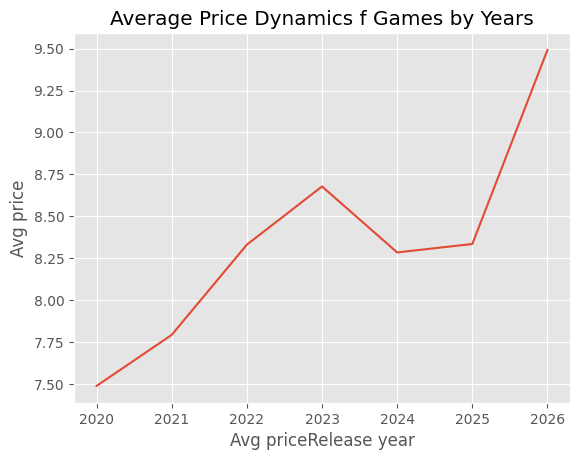

In [145]:
df.groupby(df['release_date'].dt.year)['initial_price_usd'].mean().plot()
plt.title("Average Price Dynamics f Games by Years")
plt.xlabel("Avg priceRelease year")
plt.ylabel("Avg price")
plt.show()

The line chart "Average Price Dynamics of Games by Years" reveals a consistent upward trend in the average cost of titles. Starting at approximately 7.50 in 2020, the average price has surged to 8.30 by 2025, and it keeps growing in 2026.

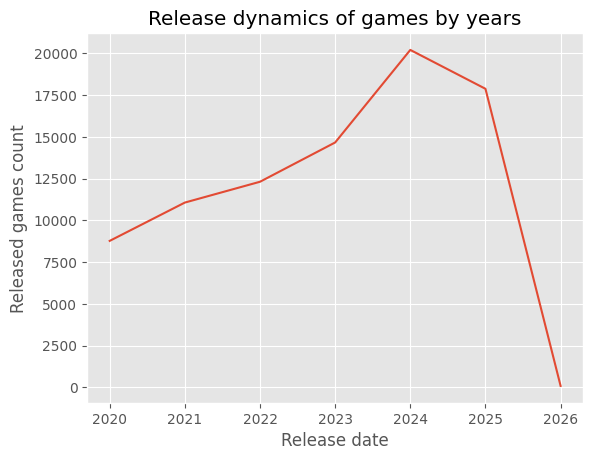

In [146]:
plt.style.use('ggplot')
df.groupby(df['release_date'].dt.year)['app_id'].count().plot()
plt.title("Release dynamics of games by years")
plt.xlabel("Release date")
plt.ylabel("Released games count")
plt.show()

We can observe a clearly pronounced positive trend in the growth of the number of released games in the period from 2020 to 2025.

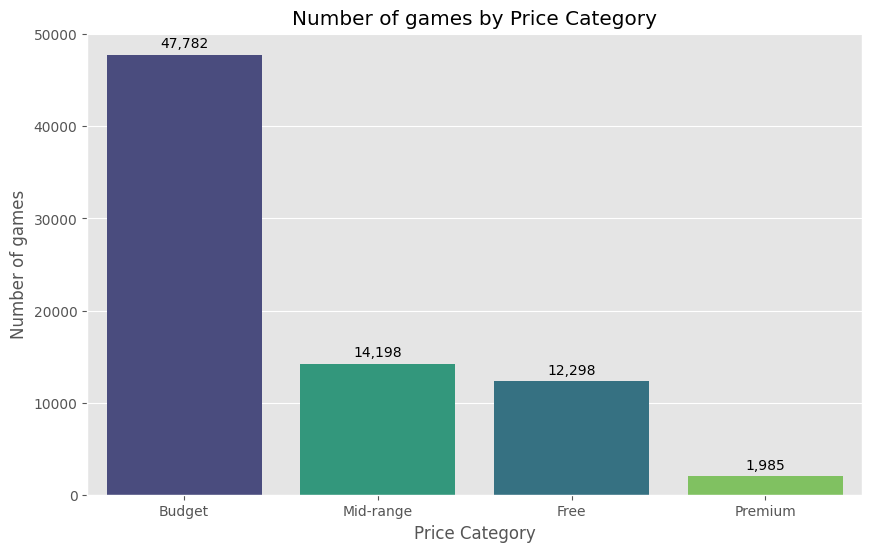

In [147]:
plt.figure(figsize = (10,6))
data = df.groupby('price_category')['app_id'].count().reset_index()
data.columns = ['price_category', 'apps_count']
order = data.sort_values(by = 'apps_count', ascending = False)['price_category']
ax = sns.barplot(data = data, x = 'price_category', y = 'apps_count', hue = 'price_category', palette = 'viridis', order = order)
for container in ax.containers:
    ax.bar_label(container, padding=3, fmt='{:,.0f}')
plt.title("Number of games by Price Category")
plt.xlabel("Price Category")
plt.ylabel("Number of games")
plt.show()

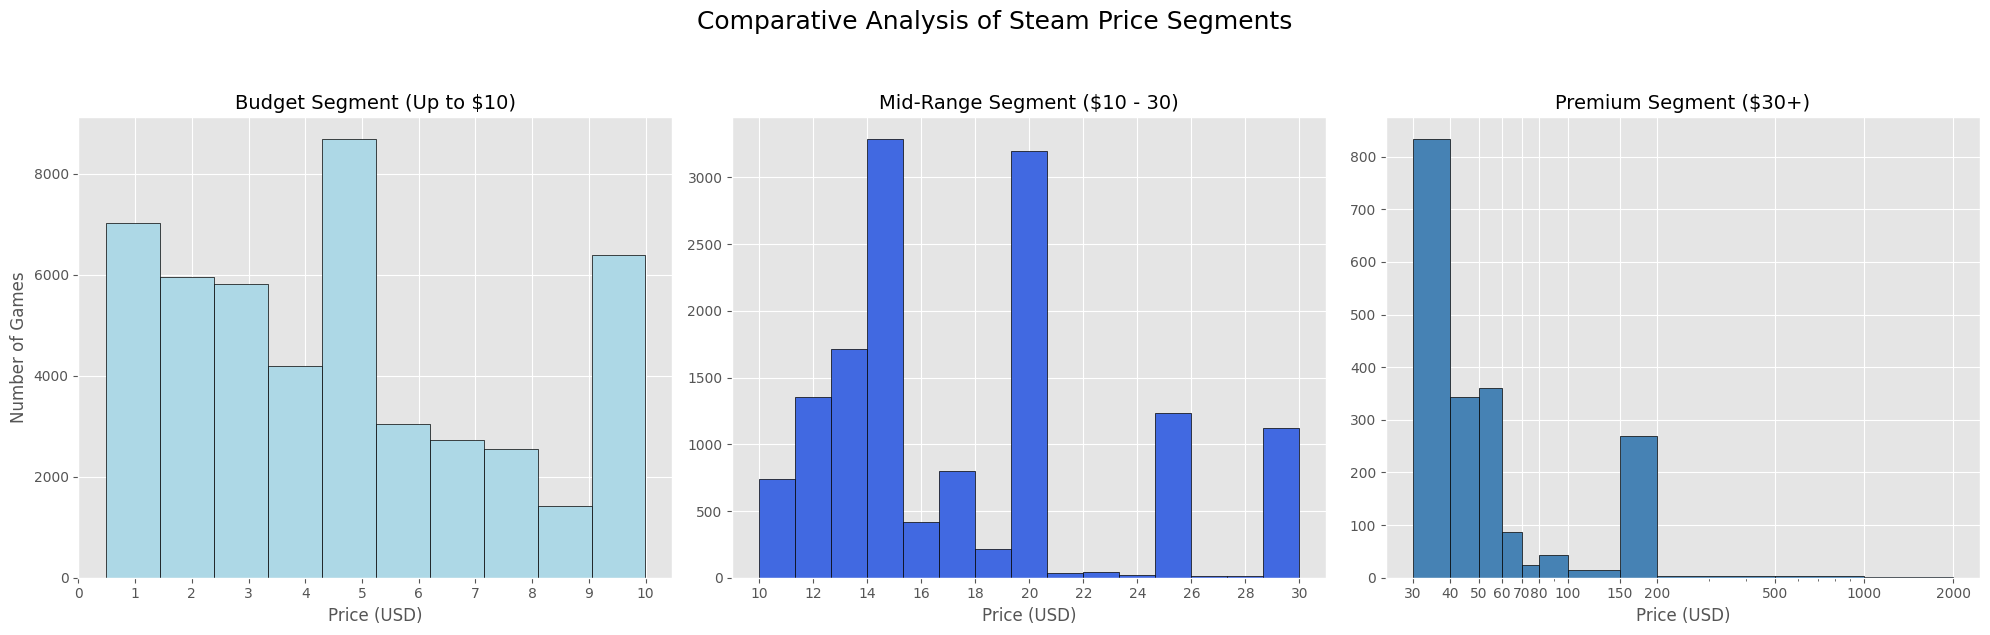

In [148]:
fig, ax = plt.subplots(1, 3, figsize=(20, 6))

data_budget = df[df['price_category'] == 'Budget']['initial_price_usd']
ax[0].hist(data_budget, bins=10, color='lightblue', edgecolor='black')
ax[0].set_title('Budget Segment (Up to $10)', fontsize=14)
ax[0].set_xlabel('Price (USD)')
ax[0].set_ylabel('Number of Games')
ax[0].set_xticks(np.arange(0, df[df['price_category'] == 'Budget']['initial_price_usd'].max() + 1, 1))

data_mid = df[df['price_category'] == 'Mid-range']['initial_price_usd']
ax[1].hist(data_mid, bins=15, color='royalblue', edgecolor='black')
ax[1].set_title('Mid-Range Segment ($10 - 30)', fontsize=14)
ax[1].set_xlabel('Price (USD)')
ax[1].set_xticks(np.arange(10, df[df['price_category'] == 'Mid-range']['initial_price_usd'].max() + 2, 2))

data_premium = df[df['price_category'] == 'Premium']['initial_price_usd']
custom_bins = [30, 40, 50, 60, 70, 80, 100, 150, 200, 500, 1000, 2000]

ax[2].hist(data_premium, bins=custom_bins, color='steelblue', edgecolor='black')
ax[2].set_xscale('log')
ax[2].set_xticks(custom_bins)
ax[2].get_xaxis().set_major_formatter(plt.ScalarFormatter())
plt.setp(ax[2].get_xticklabels(), rotation = 0)

ax[2].set_title('Premium Segment ($30+)', fontsize=14)
ax[2].set_xlabel('Price (USD)')

plt.suptitle('Comparative Analysis of Steam Price Segments', fontsize=18, y=1.05)
plt.tight_layout()
plt.show()

- Budget Segment (0–10): The distribution is multi-modal. There are clear, dominant peaks at the mid-point (approx. 5) and at the upper boundary (10). This suggests a standardized pricing approach for low-cost titles.

- Mid-Range Segment (10–30): This segment shows the most internal variance. We see distinct clusters of games at 15, 20, and 30. The frequency remains relatively high compared to the Premium tier but shows a sharp drop-off after the $20 mark.

- Premium Segment (30+): By utilizing a logarithmic scale, we can observe that the vast majority of premium titles are concentrated at the lower end of this scale (between 30 and 60). The distribution effectively visualizes the presence of extreme outliers, with a sparse but visible number of titles reaching up to 2,000.

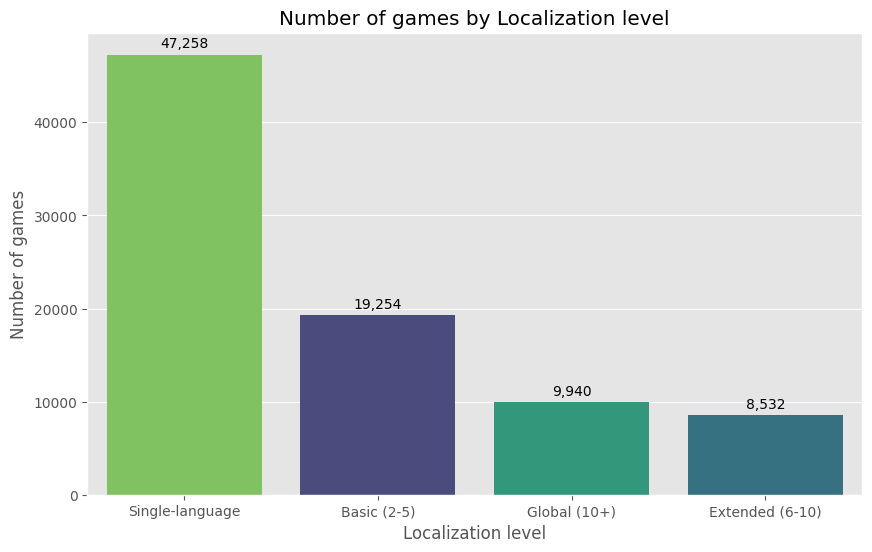

In [149]:
plt.figure(figsize = (10,6))
data = df.groupby('localization_level')['app_id'].count().reset_index()
data.columns = ['localization_level', 'apps_count']
order = data.sort_values(by = 'apps_count', ascending = False)['localization_level']
ax = sns.barplot(data = data, x = 'localization_level', y = 'apps_count', hue = 'localization_level', palette = 'viridis', order = order)
for container in ax.containers:
    ax.bar_label(container, padding=3, fmt='{:,.0f}')
plt.title("Number of games by Localization level")
plt.xlabel("Localization level")
plt.ylabel("Number of games")
plt.show()

- **Dominance of single‑language projects:** There is a significant gap between the categories. The vast majority of games (over 47,000) support only one language, which is typical for the indie segment and niche releases.

- **Inverse relationship:** The number of games decreases sharply as the level of localization increases. Projects supporting more than 10 languages (“Global”) appear almost five times less frequently than single‑language titles.

- **Market standard:** The “Basic (2–5)” category is the most common step for expanding audience reach beyond minimal localization, covering around 19,000 applications.
- Strategy of wide coverage: An interesting anomaly is that games supporting 6–10 languages (“Extended”) appear less frequently than projects supporting 10+ languages (“Global”).
This indicates that companies rarely stop at an intermediate stage. If the budget allows going beyond basic localization (2–5 languages), developers tend to move directly to the maximum expanded level to cover all key global markets at once.

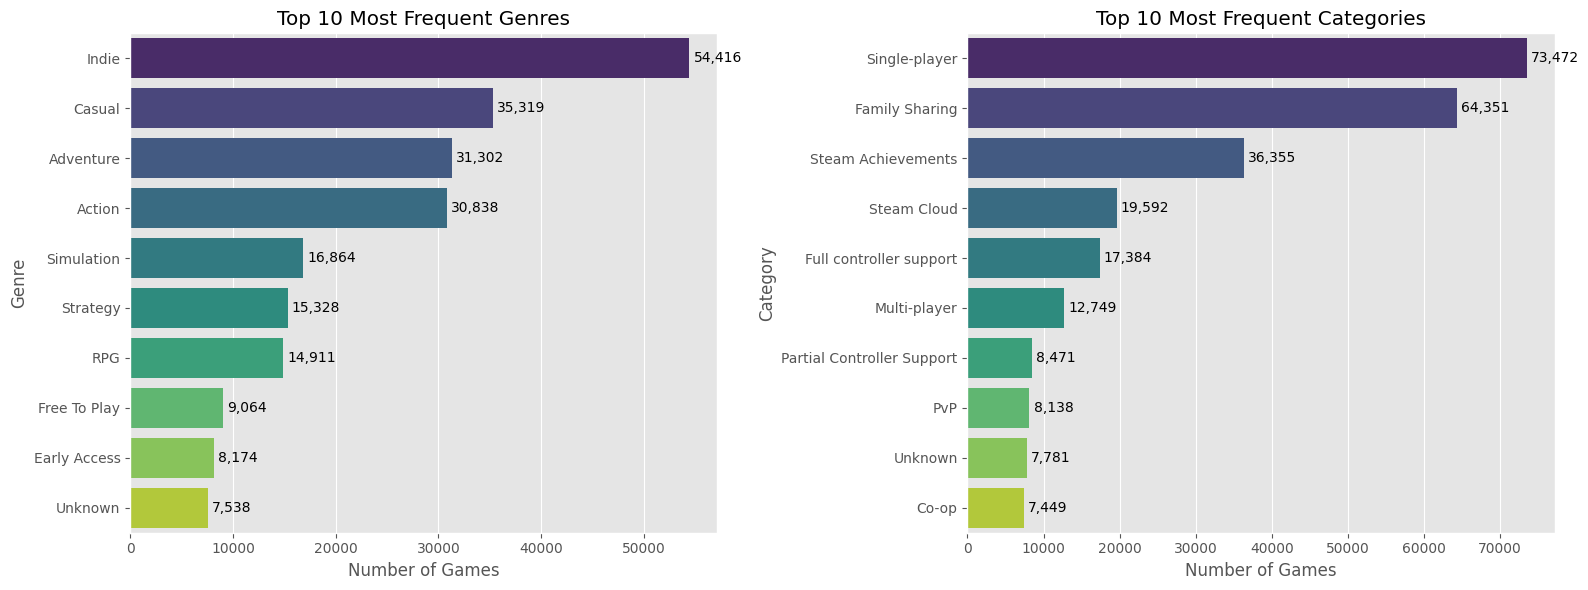

In [150]:
fig, ax = plt.subplots(1,2,figsize = (16,6))
df['genres_split'] = df['genres_list'].str.split(', ')
genres_exploded = df.explode('genres_split')
top_genres = genres_exploded['genres_split'].value_counts().head(10).reset_index()
top_genres.columns = ['Genre', 'Games Count']

sns.barplot(data=top_genres, x='Games Count', y='Genre', hue='Genre', palette='viridis', ax = ax[0])
for container in ax[0].containers:
    ax[0].bar_label(container, padding=3, fmt='{:,.0f}')

ax[0].set_title('Top 10 Most Frequent Genres')
ax[0].set_xlabel('Number of Games')
ax[0].set_ylabel('Genre')

df['categories_split'] = df['categories_list'].str.split(', ')
genres_exploded = df.explode('categories_split')
top_genres = genres_exploded['categories_split'].value_counts().head(10).reset_index()
top_genres.columns = ['Category', 'Games Count']

sns.barplot(data=top_genres, x='Games Count', y='Category', hue='Category', palette='viridis', ax = ax[1])
for container in ax[1].containers:
    ax[1].bar_label(container, padding=3, fmt='{:,.0f}')

ax[1].set_title('Top 10 Most Frequent Categories')
ax[1].set_xlabel('Number of Games')
ax[1].set_ylabel('Category')
plt.tight_layout()
plt.show()

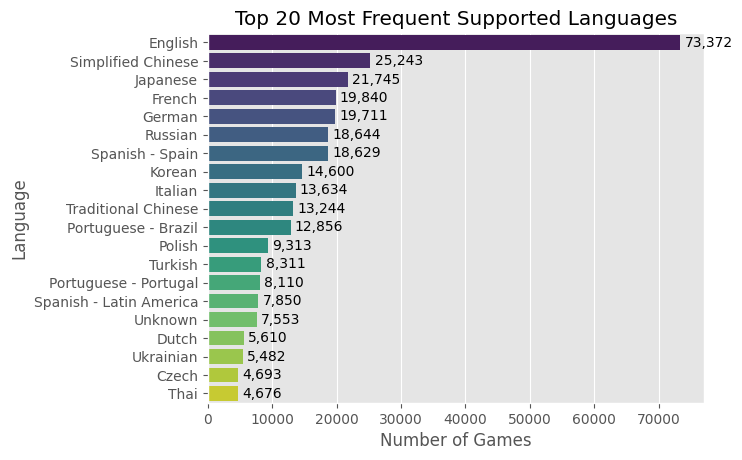

In [151]:
df['languages_split'] = df['supported_languages'].str.split(', ')
genres_exploded = df.explode('languages_split')
top_genres = genres_exploded['languages_split'].value_counts().head(20).reset_index()
top_genres.columns = ['Language', 'Games Count']

ax = sns.barplot(data=top_genres, x='Games Count', y='Language', hue='Language', palette='viridis')
for container in ax.containers:
    ax.bar_label(container, padding=3, fmt='{:,.0f}')

plt.title('Top 20 Most Frequent Supported Languages')
plt.xlabel('Number of Games')
plt.ylabel('Language')
plt.show()

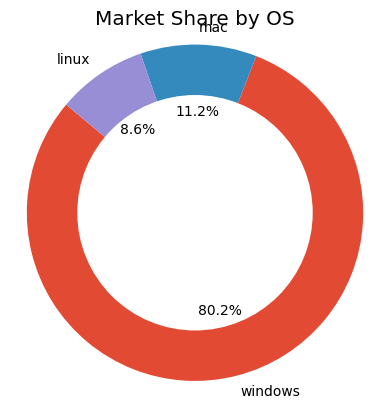

In [152]:
plt.figure(figsize=(4, 4))
df['platforms_list_split'] = df['platforms_list'].str.split(', ')
platforms_exploded = df.explode('platforms_list_split')
platform_counts = platforms_exploded['platforms_list_split'].value_counts()
labels = platform_counts.index
sizes = platform_counts.values

plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140)
centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.axis('equal')
plt.tight_layout()
plt.title('Market Share by OS')
plt.show()

#Deep Diagnostic Analytics

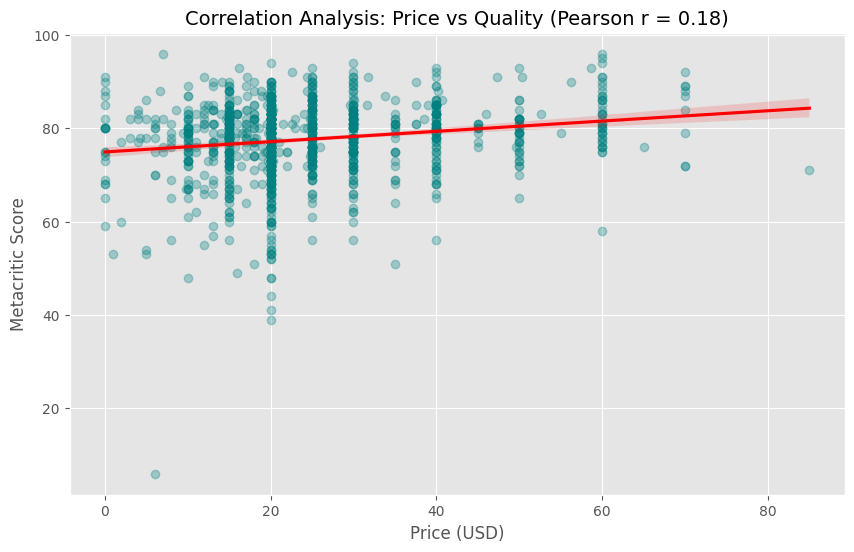

Test statistic and p-value: PearsonRResult(statistic=np.float64(0.17759934160253094), pvalue=np.float64(1.7229538192893842e-09))


In [153]:
from scipy.stats import pearsonr
corr_df = df.dropna(subset=['initial_price_usd', 'metacritic_score'])
correlation = corr_df['initial_price_usd'].corr(corr_df['metacritic_score'])
plt.figure(figsize=(10, 6))
sns.regplot(data=corr_df, x='initial_price_usd', y='metacritic_score', scatter_kws={'alpha':0.3, 'color':'teal'}, line_kws={'color':'red'})
plt.title(f'Correlation Analysis: Price vs Quality (Pearson r = {correlation:.2f})', fontsize=14)
plt.xlabel('Price (USD)')
plt.ylabel('Metacritic Score')
plt.show()

print(f"Test statistic and p-value: {pearsonr(corr_df['metacritic_score'], corr_df['initial_price_usd'])}")

Pearson Correlation Coefficient ($r$): $0.18$

p-value: $1.72 \times 10^{-9}$


The analysis reveals a statistically significant ($p < 0.05$) but weak positive correlation between initial_price_usd and metacritic_score. While the low p-value suggests that the relationship is not due to random chance, the $r$-value of $0.18$ indicates that price is a poor predictor of critical quality.

A critical constraint of this analysis is the extremely low data density: titles with an available metacritic_score represent only approximately 1.5% of the total dataset. Due to this severe sample size limitation and the weak correlation strength, these findings should be treated as inconclusive. It is not advisable to draw definitive market-wide conclusions regarding the "Price-to-Quality" ratio based solely on this subset.

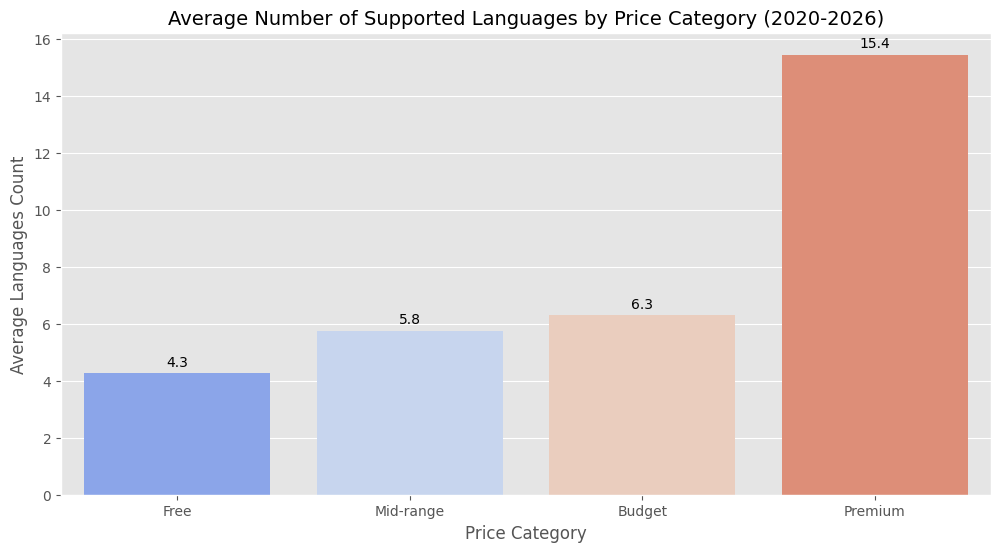

In [154]:
plt.figure(figsize=(12, 6))
lang_price = df.groupby('price_category')['lang_count'].mean().sort_values()

ax = sns.barplot(x=lang_price.index, y=lang_price.values, palette='coolwarm', hue=lang_price.index, legend=False)
for container in ax.containers:
  ax.bar_label(container, padding=3, fmt='{:,.1f}')

plt.title('Average Number of Supported Languages by Price Category (2020-2026)', fontsize=14)
plt.ylabel('Average Languages Count')
plt.xlabel('Price Category')
plt.show()

- Games in the premium category typically support a larger number of languages — approximately 15–16.
- Mid‑budget and low‑budget games support roughly the same number of languages, around 6.
- Free‑to‑play games support an average of 4 languages, which is not significantly lower than games in the low‑ and mid‑price ranges.

In [155]:
df['release_year'] = df['release_date'].dt.year

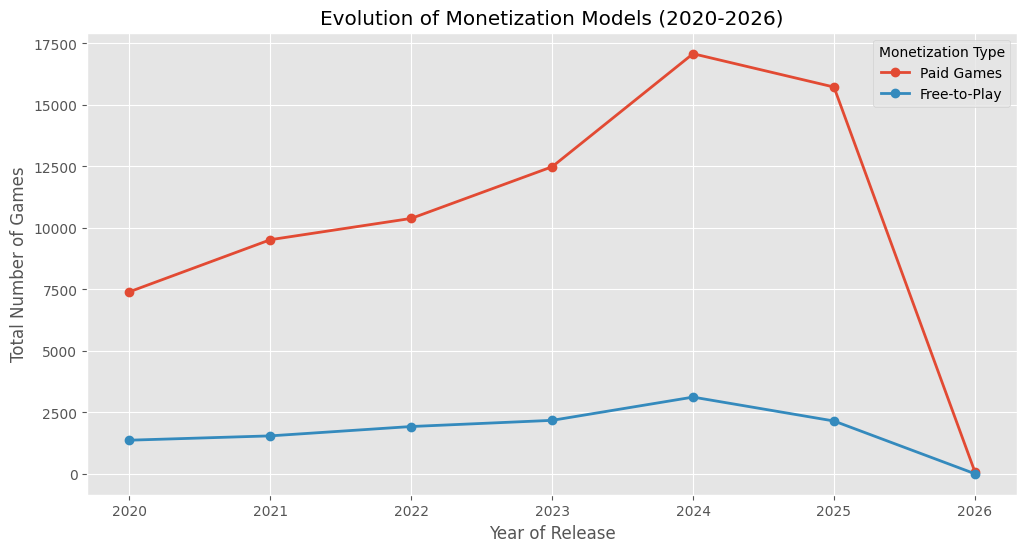

In [156]:
trends = df.pivot_table(index = 'release_year', columns = 'is_free', values = 'app_id', aggfunc = 'count', fill_value = 0)
trends.columns = ['Paid Games', 'Free-to-Play']
trends.plot(kind='line', figsize=(12, 6), marker='o', linewidth=2)
plt.title('Evolution of Monetization Models (2020-2026)')
plt.xlabel('Year of Release')
plt.ylabel('Total Number of Games')
plt.legend(title='Monetization Type')

plt.show()

The dynamics of paid game releases significantly outpace free ones. While the Free‑to‑Play segment shows moderate and stable growth, the number of paid releases has nearly doubled (from 7,500 in 2020 to a peak of over 17,000 in 2024).
The Steam market remains oriented toward the classic model of selling game copies, which is confirmed by the sharp upward trend of the red line.
The large number of paid games correlates with the high count of single‑language projects (47k). This indicates that the market is being filled with a substantial number of small paid indie projects that have limited budgets both for localization and for implementing complex F2P monetization models.

In [157]:
df_active = df[df['recommendations_total'] > 0].copy()
top_10_threshold = df_active['recommendations_total'].quantile(0.9)
df_active['is_hit'] = df_active['recommendations_total'] >= top_10_threshold
def get_custom_mode(series):
    return series.str.split(', ').explode().mode()[0]
hit_profile = df_active.groupby('is_hit').agg({
    'initial_price_usd': 'mean',
    'lang_count': 'mean',
        'is_free': 'mean',
    'genres_list': get_custom_mode,
    'categories_list': get_custom_mode
}).reset_index()

hit_profile.columns = [
    'Is Hit', 'Avg Price', 'Avg Languages',
    'Free-to-Play Share', 'Top Genre (Mode)', 'Top Category (Mode)'
]

hit_profile.head()

,Is Hit,Avg Price,Avg Languages,Free-to-Play Share,Top Genre (Mode),Top Category (Mode)
0,False,15.138346,7.710930,0.011229,Indie,Family Sharing
1,True,27.554837,11.009268,0.014829,Action,Single-player


The 'Hit Formula' is not a single variable, but a synergy of parameters. Analysis proves that success on Steam is statistically linked to higher-than-average pricing ($27.55), extensive localization (11 languages), and alignment with the most popular genre (Action). This methodology allows us to transform raw data into a strategic roadmap for developers.

In [158]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84984 entries, 0 to 84983
Data columns (total 25 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   app_id                 84984 non-null  int64         
 1   name                   84984 non-null  object        
 2   release_date           84984 non-null  datetime64[ns]
 3   is_free                84984 non-null  bool          
 4   initial_price_usd      76263 non-null  float64       
 5   final_price_usd        76263 non-null  float64       
 6   discount_percent       76263 non-null  float64       
 7   original_currency      84984 non-null  object        
 8   price_category         76263 non-null  object        
 9   type                   84984 non-null  object        
 10  genres_list            84984 non-null  object        
 11  categories_list        84984 non-null  object        
 12  platforms_list         84984 non-null  object        
 13  d